In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Statistics

Population Parameter:

Sample Statistic: 


In [3]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


In [4]:
# (Population) Parameter
np.median(united.column('Delay'))

2.0

In [5]:
# (Sample) Statistic
np.median(united.sample(10).column('Delay'))

5.0

In [6]:
# (Sample) Statistic
np.median(united.sample(100).column('Delay'))

3.0

### Probability & Empirical Distributions of a Statistic

In [7]:
def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [8]:
sample_median(10)

1.0

In [9]:
num_simulations = 2000

In [10]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(10)
    sample_medians = np.append(sample_medians, new_median)

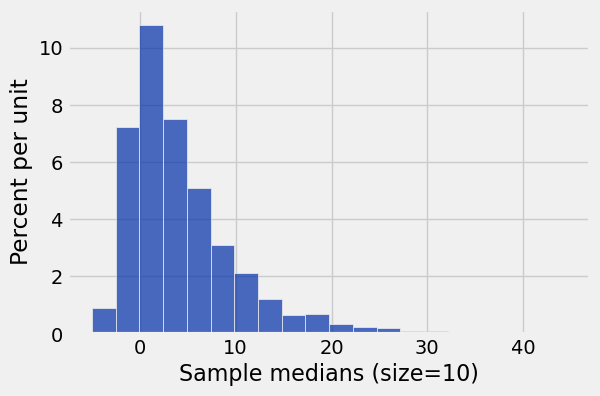

In [11]:
Table().with_column('Sample medians (size=10)', sample_medians).hist(bins=20)

In [12]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(1000)
    sample_medians = np.append(sample_medians, new_median)

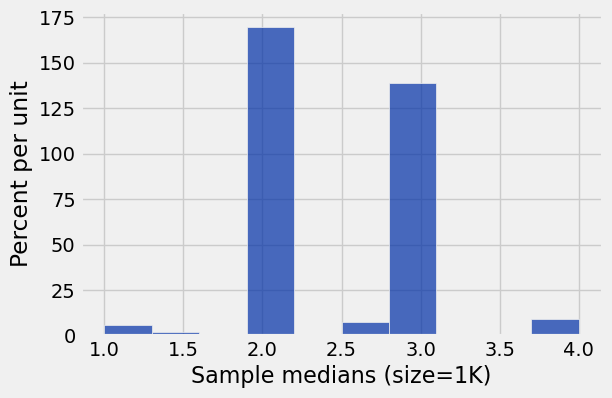

In [13]:
Table().with_column('Sample medians (size=1K)', sample_medians).hist()

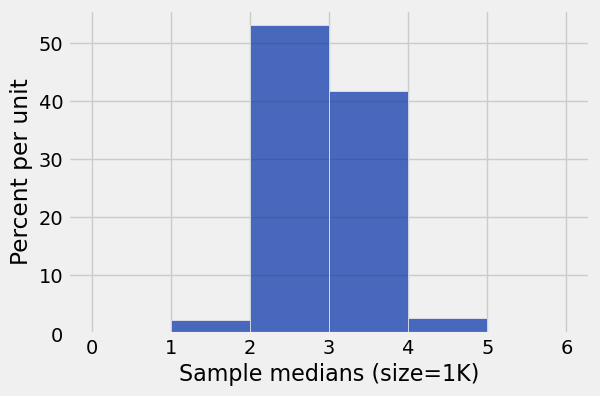

In [14]:
Table().with_column('Sample medians (size=1K)', sample_medians).hist(bins = np.arange(0, 7, 1))

#### Empirical Distributions of a Statistic (Overlayed)

Below, compare the outcome of running the simulations 2000 time each for a different size sample. 

What was the true median delay from the population?

Which sample size would help us predict the population parameter better if we didn't already know it. 


In [15]:
sample_medians_10 = make_array()
sample_medians_100 = make_array()
sample_medians_1000 = make_array()

num_simulations = 2000

for i in np.arange(num_simulations):
    new_median_10 = sample_median(10)
    sample_medians_10 = np.append(sample_medians_10, new_median_10)
    new_median_100 = sample_median(100)
    sample_medians_100 = np.append(sample_medians_100, new_median_100)
    new_median_1000 = sample_median(1000)
    sample_medians_1000 = np.append(sample_medians_1000, new_median_1000)

In [16]:
sample_medians = Table().with_columns('Size 10', sample_medians_10, 
                                      'Size 100', sample_medians_100,
                                      'Size 1000', sample_medians_1000)

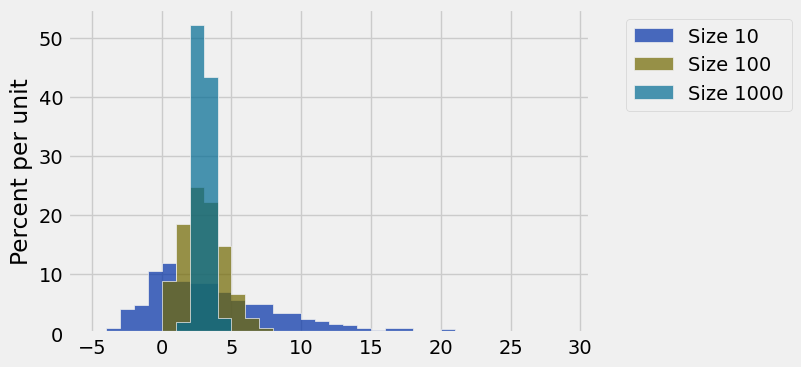

In [17]:
sample_medians.hist(bins = np.arange(-5, 30))

# Models #

A model is a set of assumptions about the data.

In data science, many models involve assumptions about processes that involve randomness </br>
“Chance models”

Key question: does the model fit the data?

## Swain vs. Alabama ##
A U.S. Supreme Court case in the 1960s. </br>
Robert Swain, a Black man, was convicted in Talladega County, AL. He appealed to the U.S. Supreme Court claiming that the jury was not impartial since there was not equal representation on the jury. </br>
According to the U.S. Constitution: Defendants have the “right to a speedy and public trial, by an impartial jury”. </br>
This means that the jury distribution of ethnicity should represent the county's distribution of ethnicty.

In Talladega County, 26% of the eligible jurors in the county were black and 74% were white at that time. Only 8 out of 100 (or 8%) black jurors were selected for the jury panel, with no black jurors selected for the Jury. The county claimed that 8 black jurors on the panel was a reasonable amount of eligible black jurors based on the distribution of the county at the time. 



### Was the Alabama jury selection process biased against the black population?


In [18]:
# Alabama's distribution of race 26% black, 74% white is modeled in the array below.

population_proportions = make_array(.26, .74)
population_proportions

array([ 0.26,  0.74])

In [20]:
# If we randomly choose 100 people from that distribution what percentages could we get?

sample_proportions(100, population_proportions)

array([ 0.26,  0.74])

In [22]:
# What does this function do?

def panel_proportion():
    return sample_proportions(100, population_proportions).item(0)

In [26]:
panel_proportion()

0.35

In [35]:
# Create an array that stores the result of running the function as a percent 10000 times. 
# Complete the code below.
panels = make_array()

for i in np.arange(10000):
    new_panel = panel_proportion()
    panels = np.append(panels, new_panel*100)
panels

array([ 17.,  18.,  37., ...,  33.,  30.,  32.])

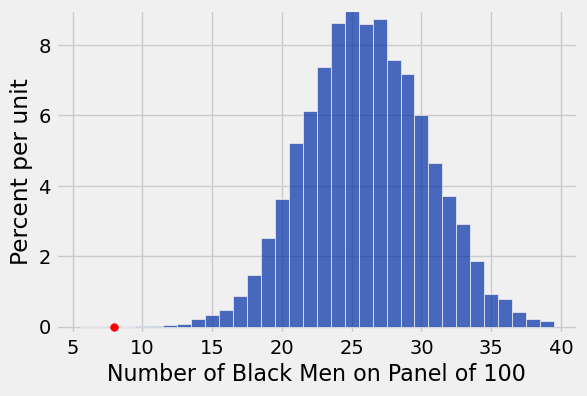

In [37]:
#Display the results as a historgram
Table().with_column(
    'Number of Black Men on Panel of 100', panels
).hist(bins=np.arange(5.5,40))


# Plotting details; this will plot Alabama's juror panel result.
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

### Was Alabama's claim that their selection process was unbiased true?

The red dot represents the number of black men on Alabama's panel of 100. 

Type your answer here.

#### About this curve: ####    
This type of curve that is roughly symmetric about a center value, is called a </br>
What is the approximate center of this curve?

Google the Empirical Rule. It shows the distrubtion of the data under a Normal curve. We can also use those value to represent the probability that a data point would fall in any given range. 

What is the approximate probability that a data point would fall at the position Alabama claimed was fair, based on the Empirical Rule?</br>
Convert the percentage into a decimal or a fraction. 

A probability below 5% is considered 


#### What type of statistic was used in this model?
    


## A Genetic Model: Mendel and Pea Flowers ##

In the 1800's, Gregor Mendel noted that when he planted pea flowers, the majority of them had purple flowers. Mendel had 929 plants. 709 of those plants had purple flowers. He determined, from his sample, that 75\% of the flowers were purple and the other 25\% were white. He hypothesized that this would be a consistent model for pea flowers. 


### Does the assumed model of 75% purple and 25% white have basis?

We want to know is the distribution close to 75\%. In this case, we don't need the value to higher or lower to prove our point, it just needs to be different enough. 

The statistic we will measure is the distance from 75\%. How do we measure distance mathematically?

In [38]:
## Mendel had 929 plants, of which 709 had purple flowers

observed_purples = 709 / 929
observed_purples

0.7631862217438106

In [39]:
#if the predicted propotions was 75% purple, when we run a random sample what propotions would we get?

predicted_proportions = make_array(.75, .25)
sample_proportions(929, predicted_proportions)

array([ 0.77717976,  0.22282024])

In [40]:
# Create a function that finds the percent of purple flowers from a random sample. 
# Refer to the code in the Swain vs. Alabama section to get some ideas. 
# Complete the code.

def purple_flowers():
    return sample_proportions(929, predicted_proportions).item(0) * 100

In [41]:
purple_flowers()

72.8740581270183

In [42]:
# Create a for loop that runs your function 10000 times and enters the result into an array. 
# Complete the code
purples = make_array()

for i in np.arange(10000):
    new_purple = purple_flowers()
    purples = np.append(purples, new_purple)

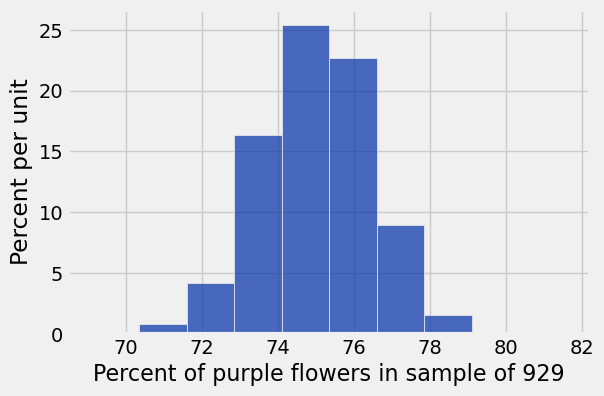

In [43]:
Table().with_column('Percent of purple flowers in sample of 929', purples).hist()

What does the above histogram reveal? Think about the model we have assumed. What does it tell us about that?

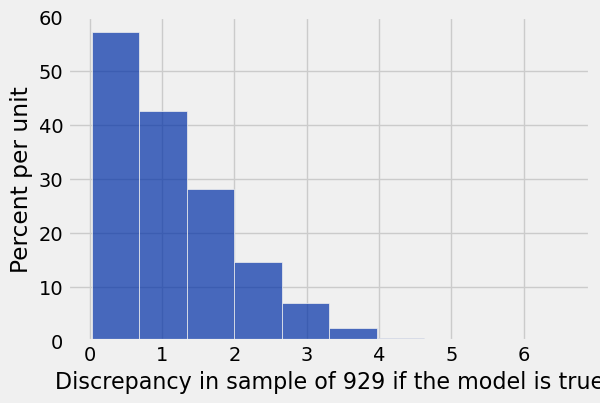

In [44]:
Table().with_column('Discrepancy in sample of 929 if the model is true', abs(purples- 75)).hist()

What is the difference between the information in this histogram compared to the first histogram? (Notice the code)

What does this reveal?

In [45]:
# In Mendel's original plants, the distribution was not exactly 75/25. 
# What was the difference between his actual percent of purples compared to his model?

abs(observed_purples * 100 - 75)

1.318622174381062

### Was Mendel's model a good fit?

Type your answer here. 

#### What type of statistic was used to test this model?

# Discussion Questions


In each of (a) and (b), what statistic will help you decide between the two viewpoints?

Data: the results of 400 tosses of a coin.

(a)

 * “This coin is fair.”   
 * “No, it’s not.”
    
(b)

 * “This coin is fair.”    
 * “No, it’s biased towards heads.

What is fair?

The percent of heads in the 400 tosses is a good starting point, but might need adjustment

A percent of heads around 50% suggests “fair

a) Very large or very small values of the percent of heads suggest “not fair.”
The distance between percent of heads and 50% is the key. </br>
○ Statistic: | percent of heads − 50% | </br>
○ Large values of the statistic suggest “not fair”

(b) Large values of the percent of heads suggest “biased towards heads” </br>
○ Statistic: percent of heads